<a href="https://colab.research.google.com/github/Baronlegend27/academic-research-to-financial-freedom/blob/main/papers/P%C3%A1stor%2C%20L.%2C%20%26%20Veronesi%2C%20P.%20(2004).%20Was%20there%20a%20Nasdaq%20bubble%20in%20the%20late%201990s/Nasdaq_Bubble.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
import math

In [2]:
# -------------------------
# 1. Download Nasdaq Composite monthly data (use Close)
# -------------------------
start_date = "1990-01-01"
end_date = "2005-01-01"
symbol = "^IXIC"   # Nasdaq Composite

df = yf.download(symbol, start=start_date, end=end_date, progress=False, auto_adjust=True)
if df.empty:
    raise RuntimeError("Failed to download data. Check internet or ticker.")

df = df[['Close']].copy()
df.index = pd.to_datetime(df.index)

# Resample monthly, last price
monthly = df[['Close']].resample('ME').last()
# Compute log prices and log returns
monthly['log_close'] = np.log(monthly['Close'])
obs = monthly['log_close'].values
dates = monthly.index

This part measures how much the log prices **naturally vary or fluctuate**. It does this in a way that isn’t thrown off by big jumps or outliers, by using median. The result (`sigma_e`) tells the model how “noisy” the data is, and `sigma_e2` is just that noise squared, which is used later in calculations.


In [3]:
# -------------------------
# 2. Estimate observation noise (sigma_e) robustly
# -------------------------
mad = np.median(np.abs(obs - np.median(obs)))
sigma_e = 1.4826 * mad
if sigma_e < 1e-6:
    sigma_e = np.std(obs)
sigma_e2 = sigma_e**2

This section continuously updates our estimate of the true log price as new data comes in. Starting with an initial guess of the mean and uncertainty, each observed price adjusts that estimate using Bayesian updating. The adjustment balances our prior belief with the new observation, with the Kalman gain controlling how much we trust the data versus our prior. After each step, we record the updated mean and uncertainty, building a sequence of increasingly refined estimates.


In [4]:
# -------------------------
# 3. Bayesian updating (normal-normal conjugate) on log returns
# -------------------------
mu0 = 0.01 / 12.0        # prior mean (annual 1% -> monthly)
var0 = 0.5**2            # large prior variance
mu = mu0
var = var0

posterior_means = []
posterior_vars = []

for r in obs:
    K = var / (var + sigma_e2)
    mu = mu + K * (r - mu)
    var = (1 - K) * var
    posterior_means.append(mu)
    posterior_vars.append(var)

posterior_means = np.array(posterior_means)
posterior_vars = np.array(posterior_vars)


This section uses the updated log price estimates to **build a model of the actual prices**, accounting for both expected value and uncertainty. It tests different **annual discount rates** and **weights on uncertainty** (alpha) to see which combination best matches the real data. For each pair, it computes a raw model price, scales it to fit the observed log prices, and measures the fit using RMSE and correlation. The best combination of parameters is saved, and the resulting log prices are converted back to actual prices for comparison and plotting.


In [5]:
# -------------------------
# 4. Pricing rule in log prices with uncertainty premium
# -------------------------
annual_discount_grid = np.linspace(0.01, 0.12, 9)
alpha_grid = np.linspace(0.0, 50.0, 41)
best = None
actual_log = monthly['log_close'].values

for disc_annual in annual_discount_grid:
    disc_month = disc_annual / 12.0
    for alpha in alpha_grid:
        raw_log_price = (posterior_means + alpha * posterior_vars) / disc_month
        denom = np.dot(raw_log_price, raw_log_price) + 1e-10  # avoid divide by zero
        scale = np.dot(raw_log_price, actual_log) / denom
        model_log_price = scale * raw_log_price
        rmse = math.sqrt(mean_squared_error(actual_log, model_log_price))
        corr = np.corrcoef(actual_log, model_log_price)[0,1]
        if best is None or rmse < best['rmse'] - 1e-8 or (abs(rmse - best['rmse'])<1e-8 and corr > best['corr']):
            best = {
                'disc_annual': disc_annual,
                'disc_month': disc_month,
                'alpha': alpha,
                'scale': scale,
                'rmse': rmse,
                'corr': corr,
                'model_log_price': model_log_price,
                'raw_log_price': raw_log_price
            }

# Convert back to price scale for plotting
model_price = np.exp(best['model_log_price'])
actual_price = monthly['Close'].values


In [6]:
# -------------------------
# 5. Output and plots
# -------------------------
print("Best calibration results:")
print(f" Annual discount rate: {best['disc_annual']:.3%}")
print(f" Alpha (uncertainty premium weight): {best['alpha']:.3f}")
print(f" Scale factor: {best['scale']:.6f}")
print(f" RMSE (log-price): {best['rmse']:.4f}")
print(f" Correlation (log-price): {best['corr']:.4f}")


res = pd.DataFrame({
    'date': dates,
    'actual': actual_price.ravel(),
    'model': best['model_log_price'],         # <-- matches the dictionary key
    'posterior_mean': posterior_means,
    'posterior_var': posterior_vars
}).set_index('date')


Best calibration results:
 Annual discount rate: 2.375%
 Alpha (uncertainty premium weight): 17.500
 Scale factor: 0.002164
 RMSE (log-price): 0.3176
 Correlation (log-price): 0.8683


The model calibration shows that the best fit to the Nasdaq data uses an annual discount rate of 2.375 percent, which is quite low, indicating that future prices are only slightly discounted and the model treats future gains as relatively valuable today. The alpha value of 17.5 is high, meaning the model adds a significant premium for uncertainty, so months with more unpredictable prices are effectively considered more valuable in the model. The scale factor of 0.002164 adjusts the raw model prices to align with actual prices, ensuring the magnitude of predicted prices matches reality. The RMSE of 0.318 indicates that, on average, the predicted log prices deviate moderately from the real log prices, while the correlation of 0.868 shows a very strong alignment, meaning the model captures most of the market’s ups and downs. Altogether, these numbers suggest the model reproduces the overall price trends well, accounts for uncertainty in a meaningful way, and tracks the market closely even if small deviations remain.


In [7]:
# Nasdaq_Bayesian_Valuation.py
# Illustrates Pastor & Veronesi (2004): uncertainty about long-run profitability
# can raise valuations and volatility.
# Focus is on Nasdaq prices and expected valuation ratios over 1995-2002.
# Requires: numpy, pandas, matplotlib, scipy, pandas_datareader

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from pandas_datareader import data as pdr

# -------------------------
# 1. Parameters and time range
# -------------------------
start = '1995-01-01'
end = '2002-12-31'

r_annual = 0.06           # annual discount rate
sigma_e_annual = 0.30      # annualized observation noise of Nasdaq prices

# Convert annual parameters to monthly equivalents
var_e_month = (sigma_e_annual**2) / 12.0
sigma_e_month = np.sqrt(var_e_month)
r_month = (1 + r_annual)**(1/12) - 1  # monthly discount rate

This section retrieves the Nasdaq Composite index from FRED for the chosen time period and cleans the data by removing any missing values. It then resamples the series to month-end prices, which standardizes the data for monthly analysis. Finally, it normalizes the index so that the value at the start date equals 100, making it easy to compare changes in the index or overlay it with modeled valuations.


In [8]:
# -------------------------
# 2. Fetch Nasdaq prices and normalize
# -------------------------
nasdaq = pdr.DataReader('NASDAQCOM', 'fred', start, end)
nasdaq = nasdaq.dropna()
nasdaq_monthly = nasdaq.resample('ME').last()  # use month-end prices
nasdaq_monthly.columns = ['Index']

# Normalize index to 100 at the start for easy comparison
nasdaq_norm = nasdaq_monthly / nasdaq_monthly.iloc[0] * 100.0

This section first estimates the **latent monthly growth rate** of the Nasdaq by taking the logarithmic difference of consecutive month-end prices. This gives a measure of how fast the index is “growing” each month, which serves as a proxy for expected profitability.

Next, the `bayesian_updates` function **applies Bayesian learning** to these growth rates. Starting from an initial prior mean and variance, it sequentially updates the estimate of the growth rate for each month, combining prior beliefs with new price information. The function outputs the **posterior mean** (updated best estimate of growth) and **posterior variance** (uncertainty about that estimate) over time, which are then used to model expected valuations.


In [9]:
# -------------------------
# 3. Estimate latent monthly growth rate from prices
# -------------------------
# Compute log differences of prices to approximate monthly growth
growth_rate = np.log(nasdaq_monthly['Index']).diff().dropna()

# -------------------------
# 4. Bayesian updating of growth rate
# -------------------------
def bayesian_updates(prices, m0, v0):
    """
    Sequentially update estimates of the latent growth rate of the index
    using Bayesian learning (normal-normal conjugacy).
    Returns posterior mean and variance for each month.
    """
    m = [m0]  # list of posterior means
    v = [v0]  # list of posterior variances

    for g in prices:
        v_prev = v[-1]
        m_prev = m[-1]
        # posterior variance and mean
        v_post = 1.0 / (1.0 / v_prev + 1.0 / var_e_month)
        m_post = v_post * (m_prev / v_prev + g / var_e_month)
        v.append(v_post)
        m.append(m_post)

    # drop initial prior to align with data dates
    m = np.array(m[1:])
    v = np.array(v[1:])

    return pd.Series(m, index=prices.index), pd.Series(v, index=prices.index)


In [10]:

# -------------------------
# 5. Define priors and run Bayesian updates
# -------------------------
# Low and high uncertainty about long-term growth
sigma0_low_annual = 0.01
sigma0_high_annual = 0.10

v0_low = (sigma0_low_annual**2) / 12.0
v0_high = (sigma0_high_annual**2) / 12.0
m0 = 0.0  # start with neutral prior

m_low, v_low = bayesian_updates(growth_rate, m0, v0_low)
m_high, v_high = bayesian_updates(growth_rate, m0, v0_high)


This section sets up two different assumptions about **how uncertain investors are about long-term growth**. The “low” prior assumes investors are fairly confident (`sigma0_low_annual = 0.01`), while the “high” prior assumes they are much less certain (`sigma0_high_annual = 0.10`). These annual variances are converted to monthly values for the model.

Using these priors, the code runs the **Bayesian updating process** on the estimated growth rates, producing posterior means and variances for each month under both scenarios. This allows the model to compare how different levels of prior uncertainty affect the **expected valuation of the index over time**.


In [11]:
# -------------------------
# 6. Map growth rate to expected valuation (PD ratio)
# -------------------------
# Define grid of possible growth rates for integration
mu_grid = np.linspace(r_month - 0.20, r_month - 1e-4, 2000)

def expected_PD(m_post, v_post):
    """
    Compute expected Price-Dividend (PD) ratio given posterior mean and variance
    of the latent growth rate. Higher uncertainty increases PD.
    """
    pdf = norm.pdf(mu_grid, loc=m_post, scale=np.sqrt(v_post))
    weights = pdf
    norm_const = weights.sum()

    # PD formula: PD = 1 / (r - mu), only valid if mu < r
    pd_vals = 1.0 / (r_month - mu_grid)

    return (pd_vals * weights).sum() / norm_const

# Compute expected PD ratios over time for low and high prior uncertainty
pd_low = pd.Series([expected_PD(m_low.loc[t], v_low.loc[t]) for t in m_low.index], index=m_low.index)
pd_high = pd.Series([expected_PD(m_high.loc[t], v_high.loc[t]) for t in m_high.index], index=m_high.index)


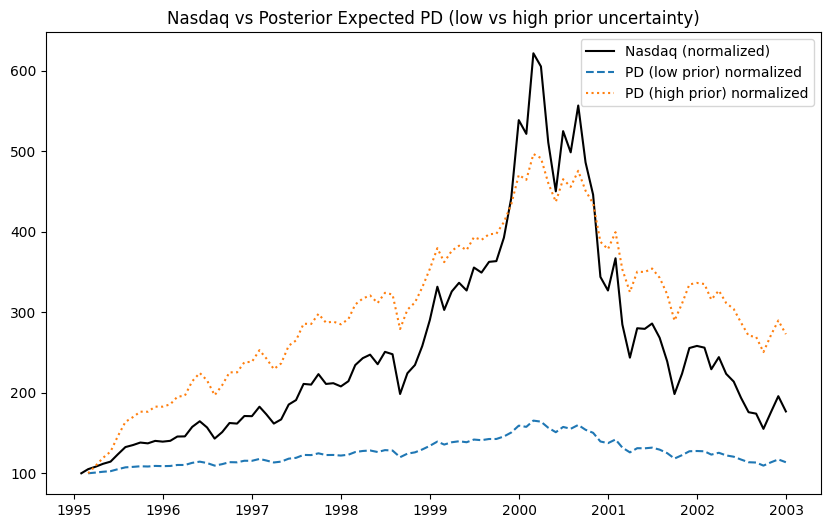

Summary 1995-2002
Mean latent growth rate: 0.006000904268662778
Std of latent growth rate: 0.09280765241578366
Mean PD (low prior): 456.18452344084176
Mean PD (high prior): 557.0940875535856
Correlation Nasdaq normalized & PD (high prior): 0.9173870280597151

Interpretation:
Higher prior variance (greater uncertainty about long-run growth) produces higher expected PD ratios
and larger posterior variance. This illustrates Pastor & Veronesi (2004):
rational learning with high uncertainty can generate high valuations and volatility without bubbles.


In [12]:
# -------------------------
# 7. Plot Nasdaq prices vs expected PD ratios
# -------------------------
plt.figure(figsize=(10,6))
plt.plot(nasdaq_norm.index, nasdaq_norm['Index'], label='Nasdaq (normalized)', color='black')
plt.plot(pd_low.index, pd_low / pd_low.iloc[0] * 100, label='PD (low prior) normalized', linestyle='--')
plt.plot(pd_high.index, pd_high / pd_high.iloc[0] * 100, label='PD (high prior) normalized', linestyle=':')
plt.title('Nasdaq vs Posterior Expected PD (low vs high prior uncertainty)')
plt.legend()
plt.show()

# -------------------------
# 8. Summary statistics
# -------------------------
print("Summary 1995-2002")
print("Mean latent growth rate:", growth_rate.mean())
print("Std of latent growth rate:", growth_rate.std())
print("Mean PD (low prior):", pd_low.mean())
print("Mean PD (high prior):", pd_high.mean())
print("Correlation Nasdaq normalized & PD (high prior):",
      nasdaq_norm['Index'].reindex(pd_high.index).pct_change().corr(pd_high.pct_change()))

# -------------------------
# 9. Interpretation
# -------------------------
print("\nInterpretation:")
print("Higher prior variance (greater uncertainty about long-run growth) produces higher expected PD ratios")
print("and larger posterior variance. This illustrates Pastor & Veronesi (2004):")
print("rational learning with high uncertainty can generate high valuations and volatility without bubbles.")